# 3-1. 취준생 AI 면접 코칭 전·후 효과성 검정

## 문제 정의

취업준비생 25명에게 AI 면접 코칭을 실시했다.
코칭 전과 후의 모의면접 점수를 비교하여,
점수 차이가 통계적으로 유의한지 확인한다.

## 이번 분석에서 답할 질문

AI 면접 코칭 전과 후의 평균 모의면접 점수는 다른가?

In [3]:
# CSV 데이터를 표 형태로 읽기 위해 pandas를 불러온다.
import pandas as pd

# 프로젝트 안의 문제해결 데이터 파일을 DataFrame으로 읽는다.
scores_df = pd.read_csv("datas2/문제해결/jobseekers_25.csv")

# 앞의 다섯 행을 출력해 열 이름과 데이터 형태를 확인한다.
print(scores_df.head())

# 행 수, 열 이름, 자료형, 결측값 여부를 확인한다.
print(scores_df.info())

   before_score  after_score
0            62           66
1            68           71
2            71           76
3            65           67
4            74           78
<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   before_score  25 non-null     int64
 1   after_score   25 non-null     int64
dtypes: int64(2)
memory usage: 532.0 bytes
None


## 2. 분석 설계와 검정 방법 선택

### 자료 구조

- 각 행은 취업준비생 한 명을 의미한다.
- `before_score`와 `after_score`는 같은 사람에게서 코칭 전·후로 측정한 점수다.
- 따라서 두 점수는 서로 독립된 자료가 아니라, 한 사람 안에서 대응되는 자료다.
- 점수는 평균을 계산할 수 있는 연속형 수치 자료다.

### 검정 방법 선택

같은 참여자 25명의 교육 전·후 평균 점수를 비교하므로
쌍체표본 t-검정(paired-samples t-test)을 사용한다.

쌍체표본 t-검정은 각 참여자의
`교육 후 점수 - 교육 전 점수` 변화량 평균이 0점인지 검정한다.

- 독립표본 t-검정은 서로 다른 두 집단을 비교할 때 사용하므로 이 문제와 맞지 않는다.
- Levene 등분산성 검정은 독립표본 t-검정의 가정 점검에 사용하므로 여기서는 필요하지 않다.
- 비교 시점이 전·후 두 개이므로 ANOVA도 사용하지 않는다.

## 3. 교육 전·후 점수와 개인별 변화량 확인

각 참여자의 변화량을 `교육 후 점수 - 교육 전 점수`로 계산한다.

- 변화량이 양수면 교육 후 점수가 상승한 것이다.
- 변화량이 음수면 교육 후 점수가 하락한 것이다.
- 변화량이 0이면 점수가 변하지 않은 것이다.

In [4]:
# 교육 전 점수 열만 선택해 before_scores 변수에 저장한다.
before_scores = scores_df["before_score"]

# 교육 후 점수 열만 선택해 after_scores 변수에 저장한다.
after_scores = scores_df["after_score"]

# 같은 참여자의 교육 후 점수에서 교육 전 점수를 빼 개인별 변화량을 계산한다.
score_changes = after_scores - before_scores

# 원본 데이터에 개인별 변화량 열을 추가한다.
scores_df["score_change"] = score_changes

# 교육 전·후 점수와 변화량의 평균을 계산해 요약표로 만든다.
mean_summary = pd.DataFrame({
    "구분": ["교육 전", "교육 후", "변화량(교육 후 - 교육 전)"],
    "평균 점수": [
        before_scores.mean(),
        after_scores.mean(),
        score_changes.mean()
    ]
})

# 각 참여자의 전·후 점수와 변화량을 앞에서 다섯 명만 출력한다.
print(scores_df.head())

# 평균 요약표를 소수 둘째 자리까지 표시한다.
display(mean_summary.round(2))

   before_score  after_score  score_change
0            62           66             4
1            68           71             3
2            71           76             5
3            65           67             2
4            74           78             4


,구분,평균 점수
0,교육 전,68.76
1,교육 후,72.76
2,변화량(교육 후 - 교육 전),4.00


## 4. 참여자별 교육 전·후 점수 변화 시각화

각 선은 한 참여자의 교육 전·후 점수를 연결한다.

- 선이 위로 향하면 교육 후 점수가 상승한 것이다.
- 선이 아래로 향하면 교육 후 점수가 하락한 것이다.
- 그래프는 변화의 방향과 개인차를 확인하는 도구이며,
  통계적 유의성은 다음 단계의 가설검정으로 판단한다.

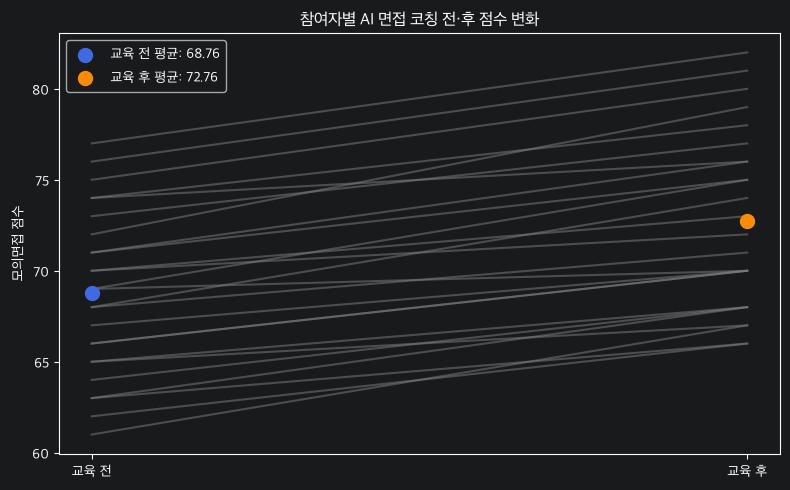

In [5]:
# 그래프를 그리기 위한 pyplot 모듈을 plt라는 이름으로 불러온다.
import matplotlib.pyplot as plt

# macOS에서 그래프의 한글이 깨지지 않도록 기본 글꼴을 설정한다.
plt.rcParams["font.family"] = "Apple SD Gothic Neo"

# 그래프에서 음수 기호가 깨지지 않도록 설정한다.
plt.rcParams["axes.unicode_minus"] = False

# 그래프 전체 크기를 가로 8인치, 세로 5인치로 설정한다.
plt.figure(figsize=(8, 5))

# 각 참여자의 교육 전·후 점수를 한 줄로 연결한다.
for before_score, after_score in zip(before_scores, after_scores):
    plt.plot(
        ["교육 전", "교육 후"],
        [before_score, after_score],
        color="gray",
        alpha=0.5
    )

# 교육 전 평균을 파란 점으로 표시한다.
plt.scatter(
    "교육 전",
    before_scores.mean(),
    color="royalblue",
    s=100,
    zorder=3,
    label=f"교육 전 평균: {before_scores.mean():.2f}"
)

# 교육 후 평균을 주황 점으로 표시한다.
plt.scatter(
    "교육 후",
    after_scores.mean(),
    color="darkorange",
    s=100,
    zorder=3,
    label=f"교육 후 평균: {after_scores.mean():.2f}"
)

# 세로축이 모의면접 점수임을 표시한다.
plt.ylabel("모의면접 점수")

# 그래프 제목을 설정한다.
plt.title("참여자별 AI 면접 코칭 전·후 점수 변화")

# 평균 점수 점들의 의미를 범례로 표시한다.
plt.legend()

# 그래프의 여백을 자동으로 조정한다.
plt.tight_layout()

# 완성한 그래프를 화면에 출력한다.
plt.show()

## 5. 변화량의 정규성 검정

쌍체표본 t-검정의 정규성 가정은 개인별 변화량이 정규분포에서 크게 벗어나지 않는다는 것이다.

표본 수가 25명으로 크지 않으므로 Shapiro-Wilk 정규성 검정을 사용한다.

- 귀무가설(H₀): 개인별 점수 변화량은 정규분포를 따른다.
- 대립가설(H₁): 개인별 점수 변화량은 정규분포를 따르지 않는다.

- p-value < 0.05: 귀무가설을 기각한다. 정규성을 위반할 가능성이 있다.
- p-value ≥ 0.05: 귀무가설을 기각하지 못한다. 정규성을 위반한다고 볼 충분한 증거가 없다.

In [6]:
# 정규성 검정과 t-검정을 위해 SciPy의 stats 모듈을 불러온다.
from scipy import stats

# 개인별 변화량에 Shapiro-Wilk 정규성 검정을 수행한다.
normality_result = stats.shapiro(score_changes)

# Shapiro-Wilk 검정통계량을 소수 넷째 자리까지 출력한다.
print(f"Shapiro-Wilk 검정통계량: {normality_result.statistic:.4f}")

# 정규성 검정의 p-value를 소수 넷째 자리까지 출력한다.
print(f"p-value: {normality_result.pvalue:.4f}")

# p-value와 유의수준 0.05를 비교해 정규성 검정 결과를 해석한다.
if normality_result.pvalue < 0.05:
    print("정규성을 위반할 가능성이 있다.")
else:
    print("정규성을 위반한다고 볼 충분한 증거가 없다.")

Shapiro-Wilk 검정통계량: 0.9633
p-value: 0.4839
정규성을 위반한다고 볼 충분한 증거가 없다.


## 6. 쌍체표본 t-검정

같은 참여자의 교육 후 점수와 교육 전 점수를 비교해,
평균 변화량이 0점인지 검정한다.

- 귀무가설(H₀): 교육 전·후 평균 모의면접 점수는 같다.
- 대립가설(H₁): 교육 전·후 평균 모의면접 점수는 다르다.

유의수준은 α = 0.05로 설정한다.

In [7]:
# 가설검정에 사용할 유의수준을 0.05로 설정한다.
alpha = 0.05

# 같은 참여자의 교육 후 점수와 교육 전 점수에 쌍체표본 t-검정을 수행한다.
paired_t_result = stats.ttest_rel(after_scores, before_scores)

# 검정 결과에서 t-통계량을 변수에 저장한다.
t_statistic = paired_t_result.statistic

# 검정 결과에서 p-value를 변수에 저장한다.
p_value = paired_t_result.pvalue

# 쌍체표본 t-검정의 자유도를 참여자 수 - 1로 계산한다.
degrees_of_freedom = len(score_changes) - 1

# t-통계량을 소수 넷째 자리까지 출력한다.
print(f"t-통계량: {t_statistic:.4f}")

# p-value를 과학적 표기법으로 출력해 매우 작은 값도 0으로 보이지 않게 한다.
print(f"p-value: {p_value:.4e}")

# 자유도를 출력한다.
print(f"자유도: {degrees_of_freedom}")

# p-value와 유의수준을 비교해 귀무가설 기각 여부를 판정한다.
if p_value < alpha:
    print("귀무가설을 기각한다: 교육 전·후 평균 점수에는 통계적으로 유의한 차이가 있다.")
else:
    print("귀무가설을 기각하지 못한다: 평균 점수가 다르다고 할 충분한 증거가 없다.")

t-통계량: 13.5873
p-value: 9.1640e-13
자유도: 24
귀무가설을 기각한다: 교육 전·후 평균 점수에는 통계적으로 유의한 차이가 있다.


## 7. 평균 변화량의 95% 신뢰구간

쌍체표본 t-검정에서 유의한 차이가 확인되었으므로,
모집단의 평균 점수 변화가 어느 범위에 있을지 95% 신뢰구간으로 확인한다.

신뢰구간이 0점을 포함하지 않으면,
평균 변화량이 0점이라는 해석과 맞지 않는다.

In [8]:
# 참여자 수를 변화량 데이터의 개수로 계산한다.
sample_size = len(score_changes)

# 개인별 변화량의 평균을 계산한다.
mean_change = score_changes.mean()

# 개인별 변화량의 표본 표준편차를 계산한다.
change_std = score_changes.std(ddof=1)

# 변화량 평균의 표준오차를 계산한다.
standard_error = change_std / (sample_size ** 0.5)

# 양측 95% 신뢰구간에 사용할 t 임계값을 계산한다.
t_critical = stats.t.ppf(1 - alpha / 2, degrees_of_freedom)

# 평균 변화량 신뢰구간의 하한을 계산한다.
ci_lower = mean_change - t_critical * standard_error

# 평균 변화량 신뢰구간의 상한을 계산한다.
ci_upper = mean_change + t_critical * standard_error

# 표본에서 관측된 평균 변화량을 출력한다.
print(f"평균 변화량: {mean_change:.2f}점")

# 모집단 평균 변화량의 95% 신뢰구간을 출력한다.
print(f"평균 변화량의 95% 신뢰구간: [{ci_lower:.2f}, {ci_upper:.2f}]점")

평균 변화량: 4.00점
평균 변화량의 95% 신뢰구간: [3.39, 4.61]점


## 8. 효과크기: Cohen's dᶻ

Cohen's dᶻ는 평균 변화량이 개인별 변화량의 표준편차에 비해
얼마나 큰지 나타내는 쌍체표본 효과크기다.

일반적인 참고 기준은 다음과 같다.

- |dᶻ| ≈ 0.2: 작은 효과
- |dᶻ| ≈ 0.5: 중간 효과
- |dᶻ| ≈ 0.8: 큰 효과

다만 이 기준은 절대적인 판정 기준이 아니므로,
실제 평균 변화량과 함께 해석한다.

In [9]:
# 평균 변화량을 변화량의 표본 표준편차로 나누어 Cohen's dz를 계산한다.
cohens_dz = mean_change / change_std

# 효과크기를 소수 둘째 자리까지 출력한다.
print(f"Cohen's dz: {cohens_dz:.2f}")

# 효과크기의 절댓값을 기준으로 참고용 크기 표현을 정한다.
if abs(cohens_dz) < 0.2:
    effect_interpretation = "매우 작은 효과"
elif abs(cohens_dz) < 0.5:
    effect_interpretation = "작은 효과"
elif abs(cohens_dz) < 0.8:
    effect_interpretation = "중간 효과"
else:
    effect_interpretation = "큰 효과"

# 평균 변화량의 방향과 효과크기 해석을 함께 출력한다.
if cohens_dz > 0:
    print(f"해석: 교육 후 점수가 높아지는 방향의 {effect_interpretation}가 관측됐다.")
else:
    print(f"해석: 교육 후 점수가 낮아지는 방향의 {effect_interpretation}가 관측됐다.")

Cohen's dz: 2.72
해석: 교육 후 점수가 높아지는 방향의 큰 효과가 관측됐다.


## 9. Wilcoxon 부호순위 검정으로 교차 확인

Wilcoxon 부호순위 검정은 같은 대상의 전·후 차이를 순위로 바꾸어 검정하는 비모수 방법이다.

- 귀무가설(H₀): 교육 전·후 점수의 중앙 변화량은 0점이다.
- 대립가설(H₁): 교육 전·후 점수의 중앙 변화량은 0점이 아니다.

쌍체표본 t-검정과 Wilcoxon 검정이 같은 결론을 보이는지 확인한다.

In [10]:
# 같은 참여자의 교육 후 점수와 교육 전 점수에 Wilcoxon 부호순위 검정을 수행한다.
wilcoxon_result = stats.wilcoxon(
    after_scores,
    before_scores,
    alternative="two-sided"
)

# Wilcoxon 검정통계량을 소수 넷째 자리까지 출력한다.
print(f"Wilcoxon 검정통계량: {wilcoxon_result.statistic:.4f}")

# Wilcoxon 검정의 p-value를 과학적 표기법으로 출력한다.
print(f"Wilcoxon p-value: {wilcoxon_result.pvalue:.4e}")

# p-value와 유의수준을 비교해 Wilcoxon 검정의 결론을 판정한다.
if wilcoxon_result.pvalue < alpha:
    print("귀무가설을 기각한다: 교육 전·후 점수 변화는 통계적으로 유의하다.")
else:
    print("귀무가설을 기각하지 못한다: 점수 변화가 유의하다고 할 충분한 증거가 없다.")

# 쌍체표본 t-검정과 Wilcoxon 검정의 유의성 결론이 같은지 확인한다.
if (p_value < alpha) == (wilcoxon_result.pvalue < alpha):
    print("쌍체표본 t-검정과 Wilcoxon 검정은 같은 유의성 결론을 보였다.")
else:
    print("두 검정의 결론이 다르므로 자료의 분포와 이상치를 추가로 살펴봐야 한다.")

Wilcoxon 검정통계량: 0.0000
Wilcoxon p-value: 1.1175e-05
귀무가설을 기각한다: 교육 전·후 점수 변화는 통계적으로 유의하다.
쌍체표본 t-검정과 Wilcoxon 검정은 같은 유의성 결론을 보였다.


## 10. 최종 결론

### 분석 방법

본 분석은 취업준비생 25명의 AI 면접 코칭 전·후 모의면접 점수를 비교했다.
같은 참여자를 코칭 전과 후에 반복 측정한 대응 자료이므로,
쌍체표본 t-검정을 사용했다.

쌍체표본 t-검정의 정규성 가정을 확인하기 위해 개인별 변화량에
Shapiro-Wilk 검정을 수행했다.
그 결과 p-value는 0.4839로 유의수준 0.05보다 컸으므로,
변화량이 정규성을 위반한다고 볼 충분한 증거는 없었다.

### 가설검정 결과

교육 전 평균 점수는 68.76점이었고,
교육 후 평균 점수는 72.76점이었다.
표본에서 관측된 평균 변화량은 4.00점 상승이었다.

쌍체표본 t-검정 결과,
t(24) = 13.59, p < .001로 나타났다.
따라서 p-value < 0.05이므로 귀무가설을 기각했다.

즉, 이 표본에서 AI 면접 코칭 전·후 평균 모의면접 점수에는
통계적으로 유의한 차이가 있었으며,
교육 후 점수가 더 높았다.

평균 변화량의 95% 신뢰구간은 [3.39, 4.61]점이었고,
Cohen's dᶻ는 2.72로 나타났다.
일반적인 참고 기준에서는 큰 효과크기에 해당한다.

Wilcoxon 부호순위 검정도 p < .001로 유의하게 나타나,
쌍체표본 t-검정과 같은 결론을 보였다.

### 해석 시 주의점

이 분석은 한 집단의 교육 전·후 점수만 비교했다.
대조군, 무작위 배정, 다른 교육·연습 경험에 대한 정보가 없으므로
AI 면접 코칭만이 점수 상승의 원인이라고 인과적으로 단정할 수는 없다.

다만, 이 표본에서는 AI 면접 코칭 후 모의면접 점수가
교육 전보다 높았다는 강한 통계적 증거가 확인되었다.